In [16]:
import numpy as np
import matplotlib.pyplot as plt

1) Regression avec SKLearn

In [17]:
np.random.seed(0)
m = 100 # creating 100 samples
X = np.linspace(0, 10, m).reshape(m, 1)
Y = X + np.random.randn(m, 1)

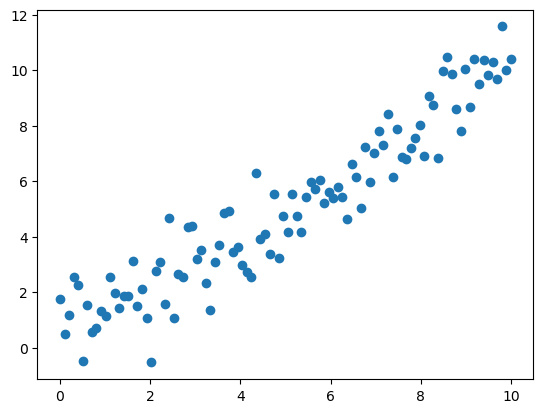

In [18]:
plt.scatter(X, Y)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

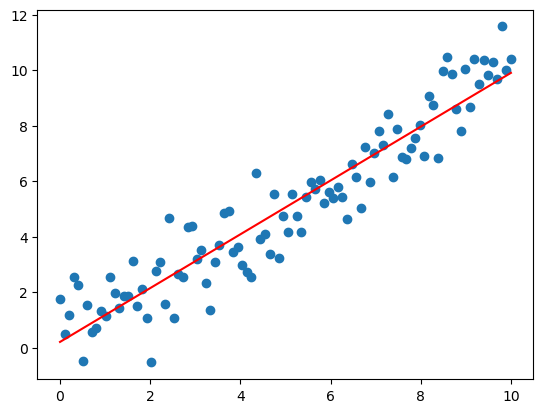

In [20]:
model = LinearRegression()
model.fit(X, Y)
model.score(X, Y)
predictions = model.predict(X)
plt.scatter(X, Y)
plt.plot(X, predictions, c='r')

Si LinearRegression n'est pas adapté : Y = X**2

In [21]:
Y = X**2 + np.random.randn(m, 1)

/home/light667/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


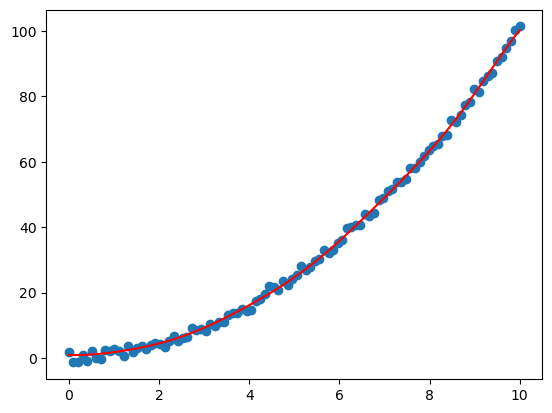

In [22]:
model = SVR(C = 100)
model.fit(X, Y)
model.score(X, Y)
predictions = model.predict(X)
plt.scatter(X, Y)
plt.plot(X, predictions, c='r')

Sklearn Classification KNN

In [25]:
import pandas as pd
import seaborn as sns

In [33]:
titanic = pd.read_excel('titanic.xls')
titanic.shape
titanic.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [35]:
titanic = titanic[['survived', 'pclass', 'sex', 'age']]
titanic.dropna(axis=0, inplace=True)
titanic['sex'].replace(['male', 'female'], [0, 1], inplace=True)
titanic.head()

/tmp/ipykernel_6062/3497883788.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic['sex'].replace(['male', 'female'], [0, 1], inplace=True)
/tmp/ipykernel_6062/3497883788.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic['sex'].replace(['male', 'female'], [0, 1], inplace=True)


,survived,pclass,sex,age
0,1,1,1,29.0000
1,1,1,0,0.9167
2,0,1,1,2.0000
3,0,1,0,30.0000
4,0,1,1,25.0000


In [36]:
from sklearn.neighbors import KNeighborsClassifier

In [37]:
model = KNeighborsClassifier()

In [38]:
y = titanic['survived']
X = titanic.drop('survived' , axis = 1)

In [39]:
X

,pclass,sex,age
0,1,1,29.0000
1,1,0,0.9167
2,1,1,2.0000
3,1,0,30.0000
4,1,1,25.0000
...,...,...,...
1301,3,0,45.5000
1304,3,1,14.5000
1306,3,0,26.5000
1307,3,0,27.0000


In [40]:
model.fit(X, y)
model.score(X, y)

0.8307839388145315

In [41]:
model.predict(X)

array([1, 1, 1, ..., 0, 0, 0])

In [49]:
def survie(model, pclass=3, sex=0, age=18):
    x= np.array([pclass, sex, age]).reshape(1, 3)
    print(model.predict(x))
    print(model.predict_proba(x))

In [50]:
survie(model, 1, 1, 49)

[1]
[[0. 1.]]


/home/light667/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/home/light667/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
